Imports


In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
df = pd.read_csv('/content/sleep_health_dataset.csv')
df.head()

,person_id,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,...,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,sleep_disorder_risk,felt_rested
0,1,29,Female,Driver,25.7,Japan,6.19,6.6,22.5,19.3,...,63,0,0,20.1,1.84,Autumn,Weekday,73.4,Healthy,0
1,2,55,Female,Software Engineer,22.0,USA,8.32,6.9,26.9,14.9,...,52,1,0,18.0,0.13,Winter,Weekend,99.4,Healthy,1
2,3,42,Male,Nurse,25.0,India,3.74,1.0,20.2,16.2,...,72,0,1,17.9,1.67,Spring,Weekend,2.5,Severe,0
3,4,37,Female,Student,29.5,India,6.79,6.4,17.7,17.7,...,71,0,0,19.1,2.37,Summer,Weekend,67.8,Healthy,0
4,5,23,Male,Lawyer,23.6,Spain,5.02,3.2,23.3,18.3,...,71,0,0,19.7,1.26,Summer,Weekday,38.1,Mild,0


In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 32 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   gender                       100000 non-null  object 
 3   occupation                   100000 non-null  object 
 4   bmi                          100000 non-null  float64
 5   country                      100000 non-null  object 
 6   sleep_duration_hrs           100000 non-null  float64
 7   sleep_quality_score          100000 non-null  float64
 8   rem_percentage               100000 non-null  float64
 9   deep_sleep_percentage        100000 non-null  float64
 10  sleep_latency_mins           100000 non-null  int64  
 11  wake_episodes_per_night      100000 non-null  int64  
 12  caffeine_mg_before_bed       100000 non-null  int64  
 13  

In [72]:
df.describe()

,person_id,age,bmi,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,sleep_latency_mins,wake_episodes_per_night,caffeine_mg_before_bed,...,nap_duration_mins,stress_score,work_hours_that_day,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,cognitive_performance_score,felt_rested
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,34.706870,26.289673,6.423986,4.871144,20.243968,20.253375,19.836810,3.346610,38.849500,...,14.936840,5.733285,7.134059,66.57017,0.561610,0.084420,20.538093,1.200634,59.227295,0.390120
std,28867.657797,11.036373,4.479578,1.274627,1.506517,3.411354,4.251096,7.584343,1.920877,69.395818,...,21.387567,1.619194,3.482878,7.22821,0.496192,0.278018,2.897565,0.786667,22.249665,0.487779
min,1.000000,18.000000,16.000000,3.000000,1.000000,10.000000,5.000000,1.000000,0.000000,0.000000,...,0.000000,1.000000,0.000000,45.00000,0.000000,0.000000,15.000000,-1.000000,0.000000,0.000000
25%,25000.750000,26.000000,23.200000,5.530000,3.800000,18.000000,17.400000,14.000000,2.000000,0.000000,...,0.000000,4.800000,4.700000,62.00000,0.000000,0.000000,18.500000,0.670000,44.200000,0.000000
50%,50000.500000,33.000000,26.300000,6.360000,4.900000,20.300000,20.300000,19.000000,3.000000,0.000000,...,0.000000,5.800000,7.400000,67.00000,1.000000,0.000000,20.500000,1.200000,60.400000,0.000000
75%,75000.250000,42.000000,29.300000,7.270000,6.000000,22.600000,23.200000,25.000000,5.000000,80.000000,...,30.000000,6.800000,9.700000,71.00000,1.000000,0.000000,22.500000,1.740000,75.800000,1.000000
max,100000.000000,69.000000,45.000000,10.500000,10.000000,30.000000,30.000000,58.000000,8.000000,400.000000,...,116.000000,10.000000,18.000000,99.00000,1.000000,1.000000,28.000000,3.000000,100.000000,1.000000


In [73]:
df.isnull().sum()

,0
person_id,0
age,0
gender,0
occupation,0
bmi,0
country,0
sleep_duration_hrs,0
sleep_quality_score,0
rem_percentage,0
deep_sleep_percentage,0


In [75]:
df.duplicated().sum()

np.int64(0)


Data Analysis (EDA)


Sleep quality by Gender

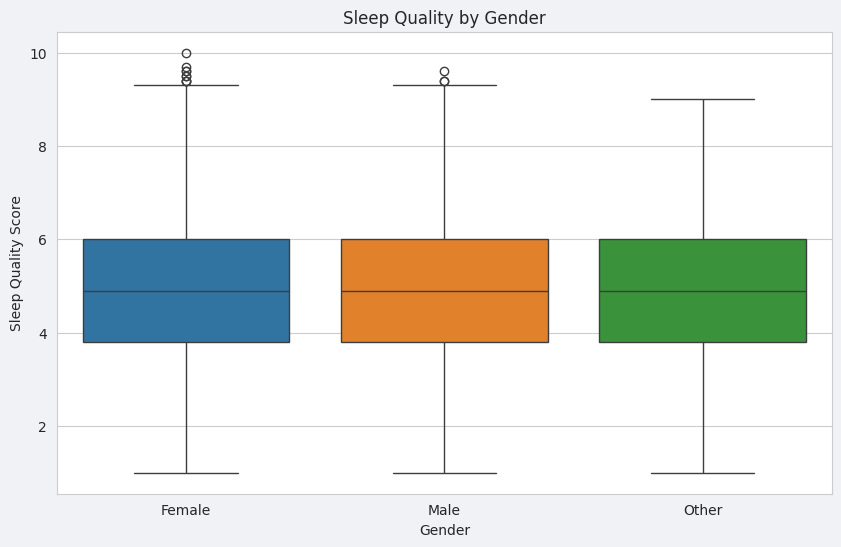

In [76]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='gender', y='sleep_quality_score', hue='gender')
plt.title('Sleep Quality by Gender')
plt.xlabel('Gender')
plt.ylabel('Sleep Quality Score')
plt.show()



 Correlation Matrix of Health Metrics


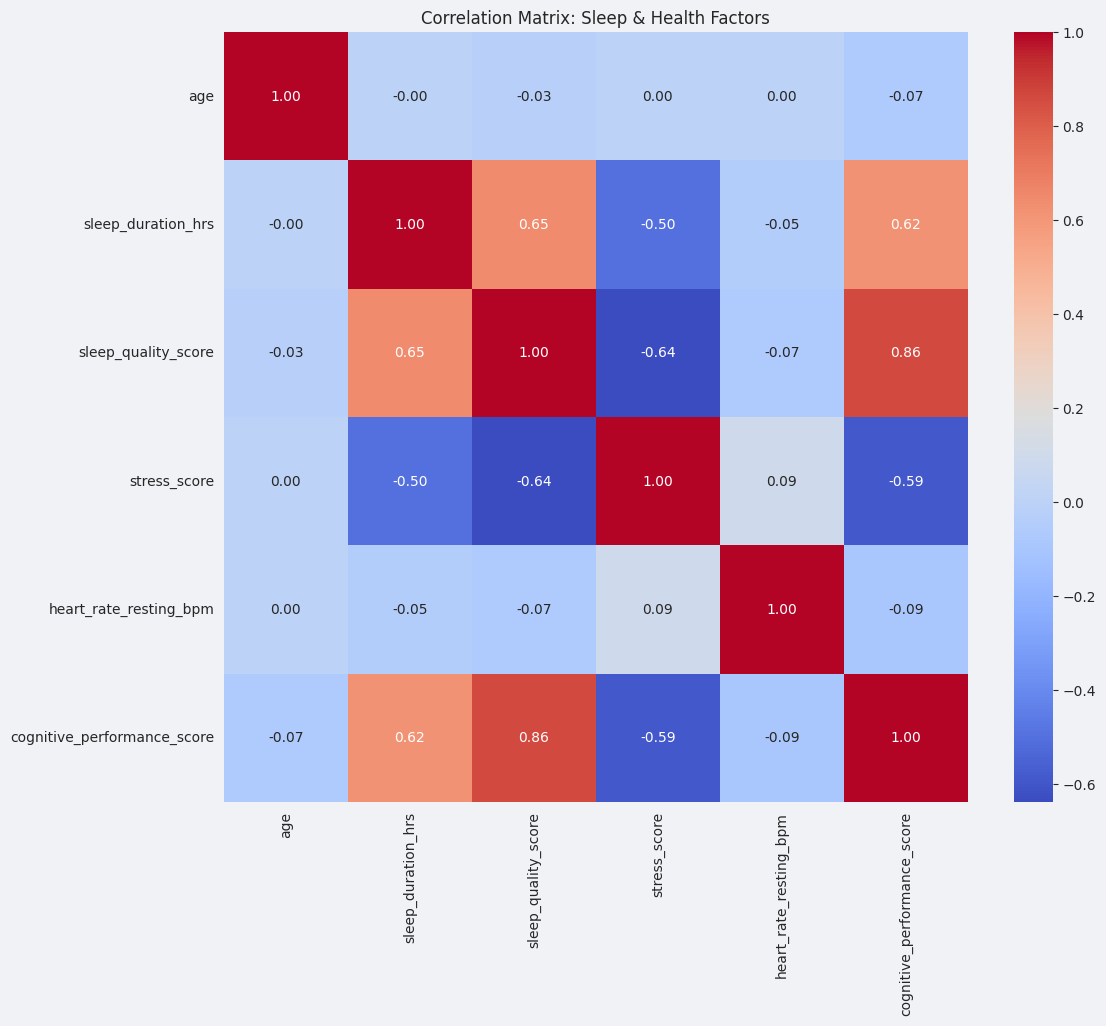

In [77]:
plt.figure(figsize=(12, 10))
corr = df[['age', 'sleep_duration_hrs', 'sleep_quality_score', 'stress_score',
           'heart_rate_resting_bpm', 'cognitive_performance_score']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix: Sleep & Health Factors')
plt.show()

 Sleep Disorder Risk across Occupations


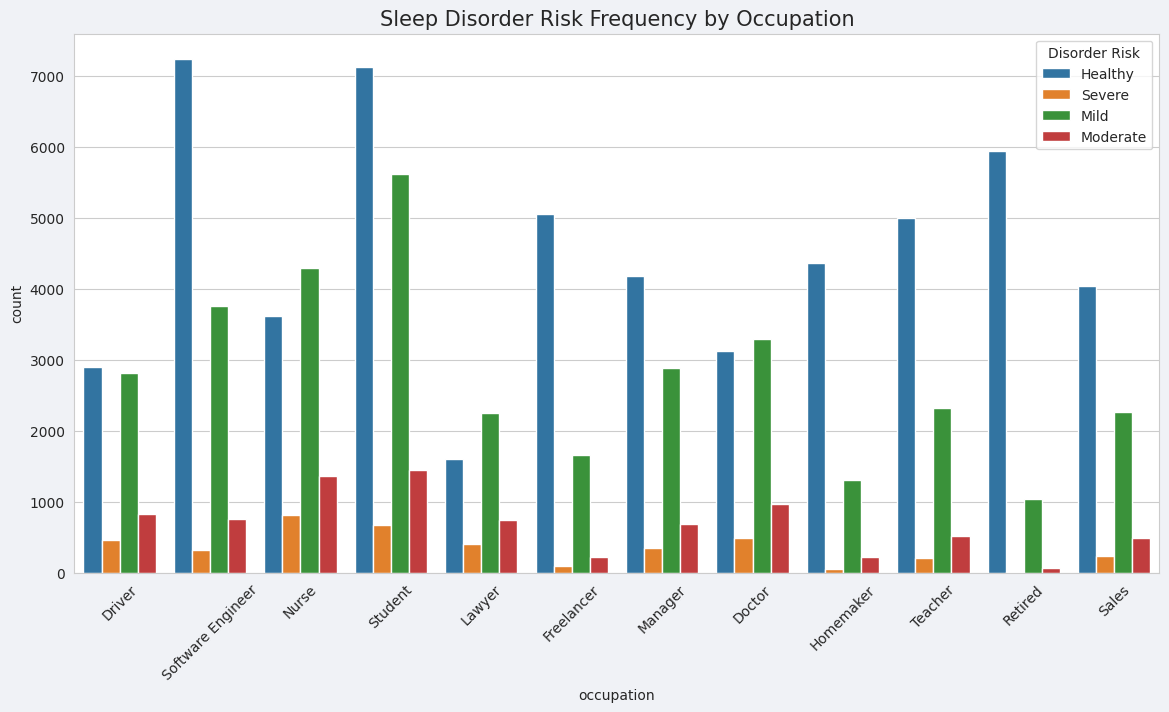

In [78]:
plt.figure(figsize=(14, 7))
sns.countplot(data=df, x='occupation', hue='sleep_disorder_risk')
plt.title('Sleep Disorder Risk Frequency by Occupation', fontsize=15)
plt.xticks(rotation=45)
plt.legend(title='Disorder Risk')
plt.show()

 Sleep Duration vs. Cognitive Performance


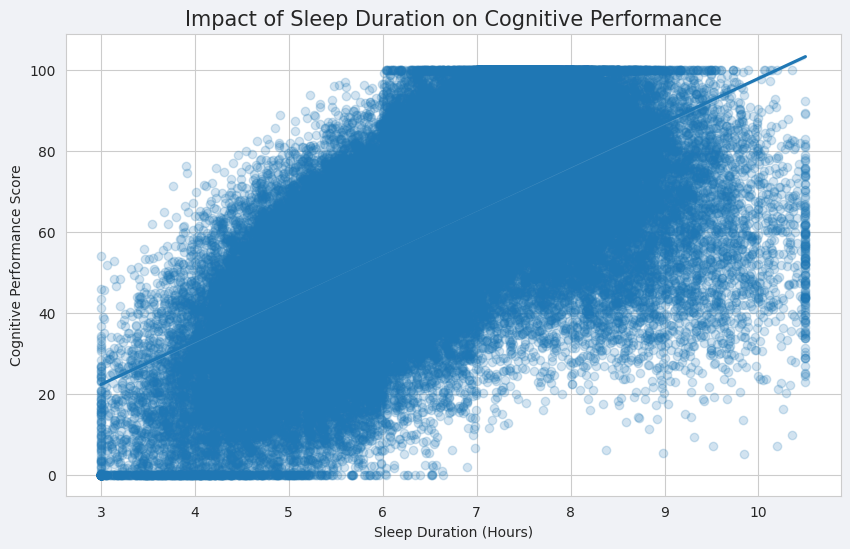

In [63]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='sleep_duration_hrs', y='cognitive_performance_score',
            scatter_kws={'alpha':0.2})
plt.title('Impact of Sleep Duration on Cognitive Performance', fontsize=15)
plt.xlabel('Sleep Duration (Hours)')
plt.ylabel('Cognitive Performance Score')
plt.show()

Caffeine Consumption vs. Sleep Latency


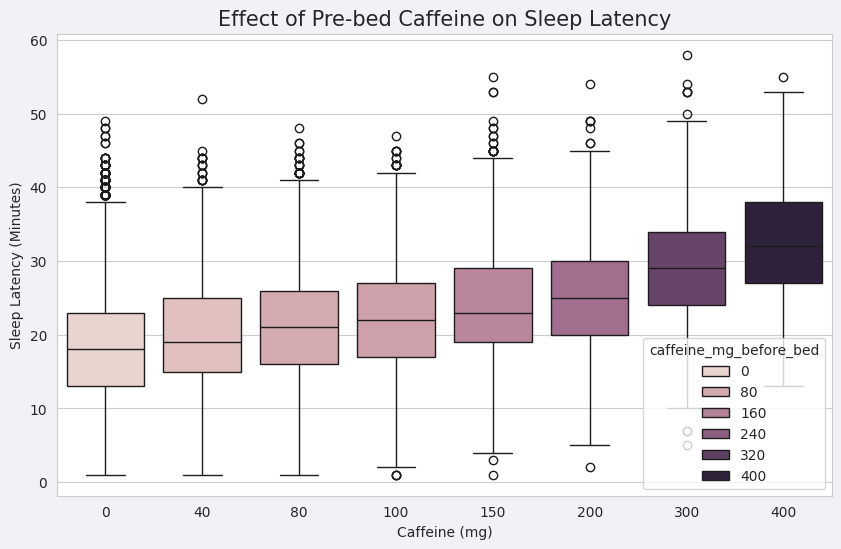

In [64]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='caffeine_mg_before_bed', y='sleep_latency_mins', hue='caffeine_mg_before_bed')
plt.title('Effect of Pre-bed Caffeine on Sleep Latency', fontsize=15)
plt.xlabel('Caffeine (mg)')
plt.ylabel('Sleep Latency (Minutes)')
plt.show()

Checking if data balanced

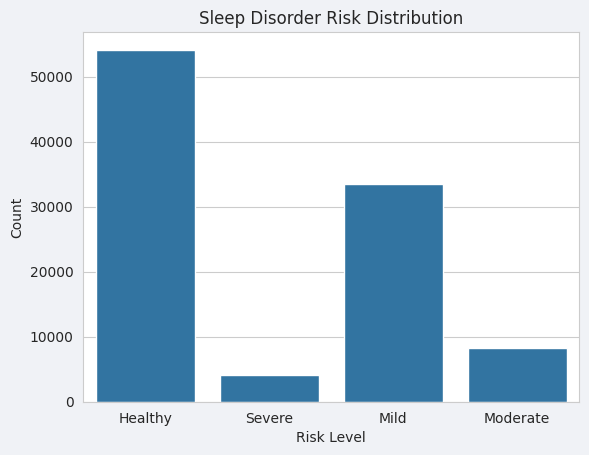

In [65]:
sns.countplot(data=df, x='sleep_disorder_risk')
plt.title('Sleep Disorder Risk Distribution')
plt.xlabel('Risk Level')
plt.ylabel('Count')
plt.show()

 Data Preprocessing & Feature Engineering


In [66]:
from imblearn.over_sampling import SMOTE

# Drop unique identifiers
df = df.drop(columns=['person_id'])

# Encode Categorical Variables
categorical_cols = ['gender', 'occupation', 'country', 'chronotype',
                    'mental_health_condition', 'season', 'day_type']
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Define Features and Target
X = df.drop(columns=['sleep_disorder_risk'])
y = df['sleep_disorder_risk']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply SMOTE for imbalanced classes
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)



 Model Training: Random Forest


In [80]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for GridSearchCV
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Initialize a RandomForestClassifier
rf_base_model = RandomForestClassifier(random_state=42)

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=rf_base_model, param_grid=param_grid,
                           cv=3, n_jobs=-1, verbose=2, scoring='accuracy')

# Fit GridSearchCV to the resampled training data
print("Starting GridSearchCV...")
grid_search.fit(X_train_resampled, y_train_resampled)
print("GridSearchCV finished.")

# Get the best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"Best Parameters: {best_params}")
print(f"Best Cross-validation Accuracy: {best_score:.2%}")

# Train the final model with the best parameters
rf_model = RandomForestClassifier(**best_params, random_state=42)
rf_model.fit(X_train_resampled, y_train_resampled)

# Make predictions on the test set
y_pred = rf_model.predict(X_test)

# Evaluation
print(f"\nModel Accuracy (with best params): {accuracy_score(y_test, y_pred):.2%}")
print("\nClassification Report (with best params):\n", classification_report(y_test, y_pred))

Starting GridSearchCV...
Fitting 3 folds for each of 16 candidates, totalling 48 fits
GridSearchCV finished.
Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 50}
Best Cross-validation Accuracy: 79.31%

Model Accuracy (with best params): 83.73%

Classification Report (with best params):
               precision    recall  f1-score   support

     Healthy       0.95      0.91      0.93     10892
        Mild       0.79      0.80      0.80      6673
    Moderate       0.49      0.57      0.53      1626
      Severe       0.65      0.70      0.67       809

    accuracy                           0.84     20000
   macro avg       0.72      0.75      0.73     20000
weighted avg       0.85      0.84      0.84     20000



 Feature Importance Analysis


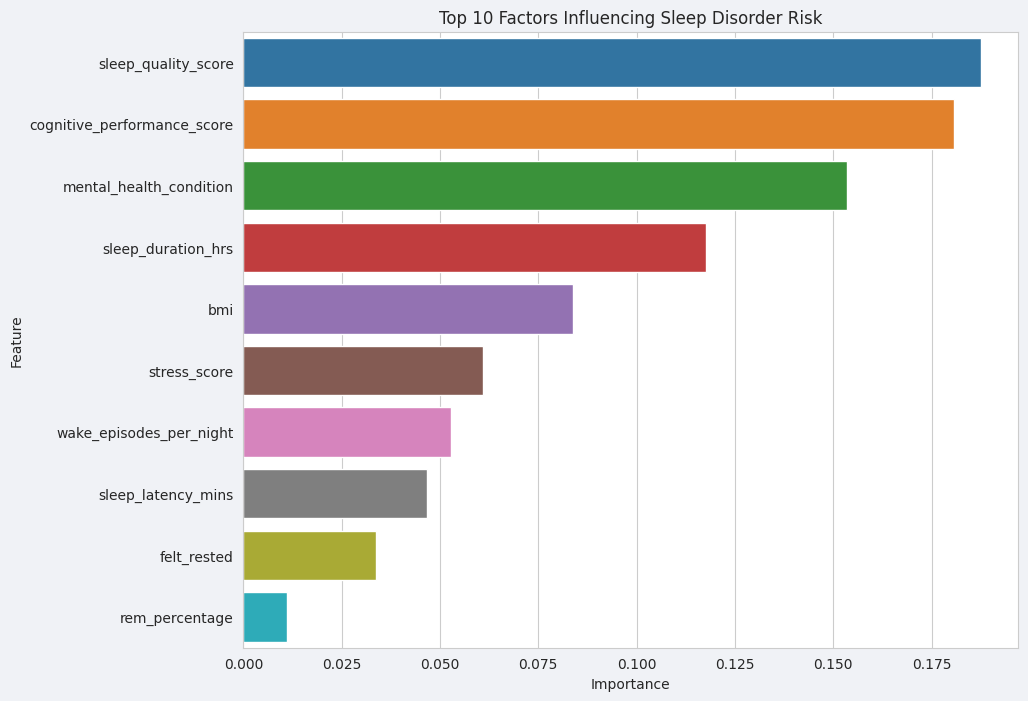

In [68]:
# Extract feature importance
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

# Visualize
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', hue='Feature', data=feature_importance_df.head(10), legend=False)
plt.title('Top 10 Factors Influencing Sleep Disorder Risk')
plt.show()

 Confusion Matrix Visualization


<Figure size 1000x800 with 0 Axes>

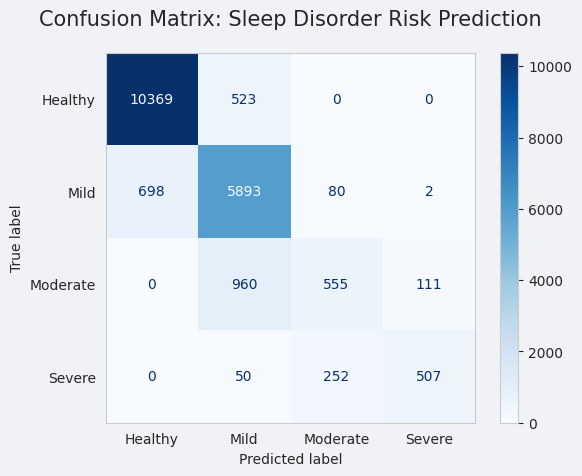

In [69]:
cm = confusion_matrix(y_test, y_pred)

labels = rf_model.classes_

# Plotting
plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues', values_format='d')

plt.title('Confusion Matrix: Sleep Disorder Risk Prediction', fontsize=15, pad=20)
plt.grid(False)
plt.show()

In [83]:
import joblib

# Define the filename for the saved model
model_filename = 'random_forest_model.pkl'

# Save the trained model to the file
joblib.dump(rf_model, model_filename)

print(f"Model successfully saved to '{model_filename}'")

Model successfully saved to 'random_forest_model.pkl'
